# The SNN Cross-Correlator (The "Bat Brain").

This implementation is a significant step up from the SISO 1D model.

Cell 1 is modified to produce torch tensors, as snntorch requires them.

Cell 2 is upgraded: it now uses an snntorch neuron (an "encoder") to convert the analog matched-filter signal back into a clean recovered_spikes train.

Cell 3 is a complete replacement. It builds the "bank" of coincidence-detecting neurons (from Paper 4) and uses them to find the time delay. It fully replaces the classical scipy.correlate algorithm.

### Cell 1: The Neural Transmitter (PyTorch Version)

This cell is modified to generate torch.Tensor spikes directly, which is necessary for the snntorch library. The physics and signal generation (convolution, modulation) are the same.

Simulation: 1000 steps at 10.0 kHz. Mean Spike Rate: 150 Hz.


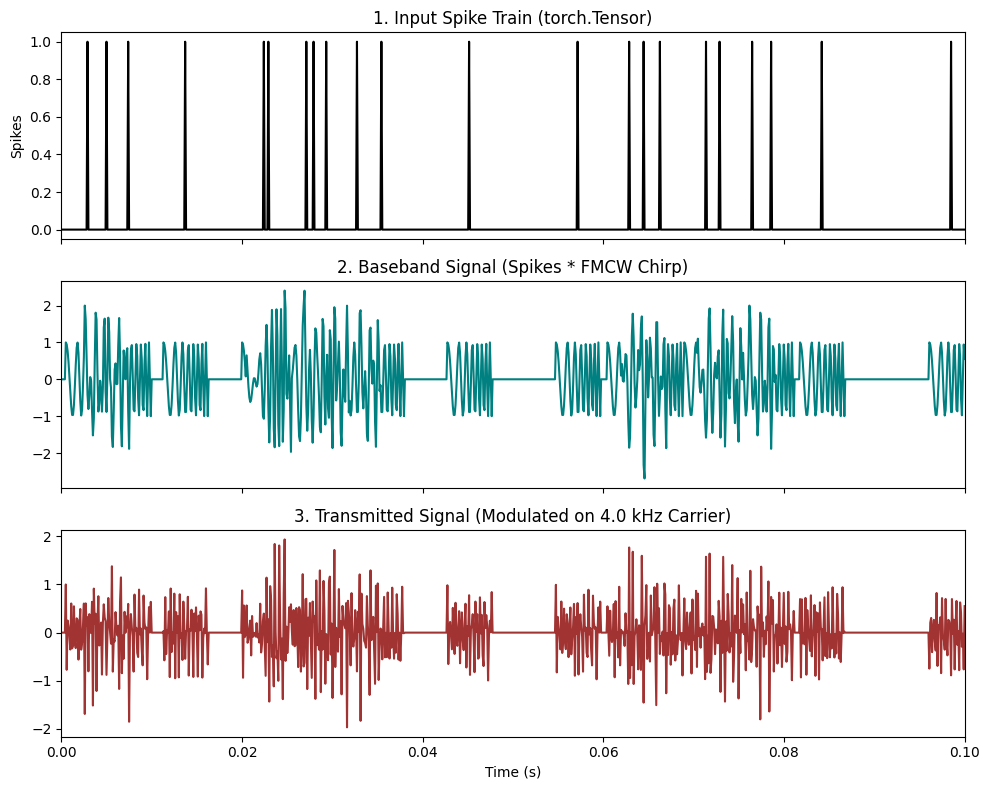

In [1]:
import torch
import snntorch as snn
from snntorch import spikeplot as splt
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# --- Parameters ---
fs = 10000        # Sampling Rate (Hz) - Lowered for faster SNN simulation
T = 0.1           # Duration of simulation (seconds)
t_vec = torch.linspace(0, T, int(fs*T)) # Use torch.linspace
time_steps = len(t_vec)

# Spike Generation Params
mean_rate_hz = 150 # Let's use a mean firing rate (more biological)
spike_prob = mean_rate_hz / fs
print(f"Simulation: {time_steps} steps at {fs/1000} kHz. Mean Spike Rate: {mean_rate_hz} Hz.")

# Radar Chirp Params
chirp_duration = 0.005 # 5ms chirp
bw = 2000              # Bandwidth
f_start = 500          # Start Freq

# Carrier Params
f_carrier = 4000       # 4 kHz Carrier

# --- 1. Generate Input Spike Train (as torch.Tensor) ---
torch.manual_seed(42)
# Generate random floats, check if below probability threshold
sent_spikes = (torch.rand(time_steps) < spike_prob).float()

# --- 2. Generate the Base Waveform (FMCW Chirp) ---
t_chirp_np = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template_np = signal.chirp(t_chirp_np, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')

# --- 3. The Sifting Theorem (Convolution) ---
# Need to use numpy for scipy.signal
sent_spikes_np = sent_spikes.numpy()
baseband_signal_np = signal.convolve(sent_spikes_np, chirp_template_np, mode='same')

# --- 4. Modulation (Put on Carrier) ---
carrier_np = np.cos(2 * np.pi * f_carrier * t_vec.numpy())
tx_signal_np = baseband_signal_np * carrier_np

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t_vec, sent_spikes, color='black')
ax[0].set_title("1. Input Spike Train (torch.Tensor)")
ax[0].set_ylabel("Spikes")
ax[0].set_xlim(0, T)

ax[1].plot(t_vec, baseband_signal_np, color='teal')
ax[1].set_title("2. Baseband Signal (Spikes * FMCW Chirp)")

ax[2].plot(t_vec, tx_signal_np, color='darkred', alpha=0.8)
ax[2].set_title(f"3. Transmitted Signal (Modulated on {f_carrier/1000} kHz Carrier)")
ax[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### Cell 2: Channel & SNN Spike Encoder

This cell is upgraded. After the matched filter produces an analog recovered_signal, we feed this signal as a current into a new snntorch.Leaky neuron. This neuron's job is to "clean up" the signal and produce a clean recovered_spikes train, which our "bat brain" will use in Cell 3.

Target Distance: 5.0m | Time of Flight: 29.15 ms (291 samples)


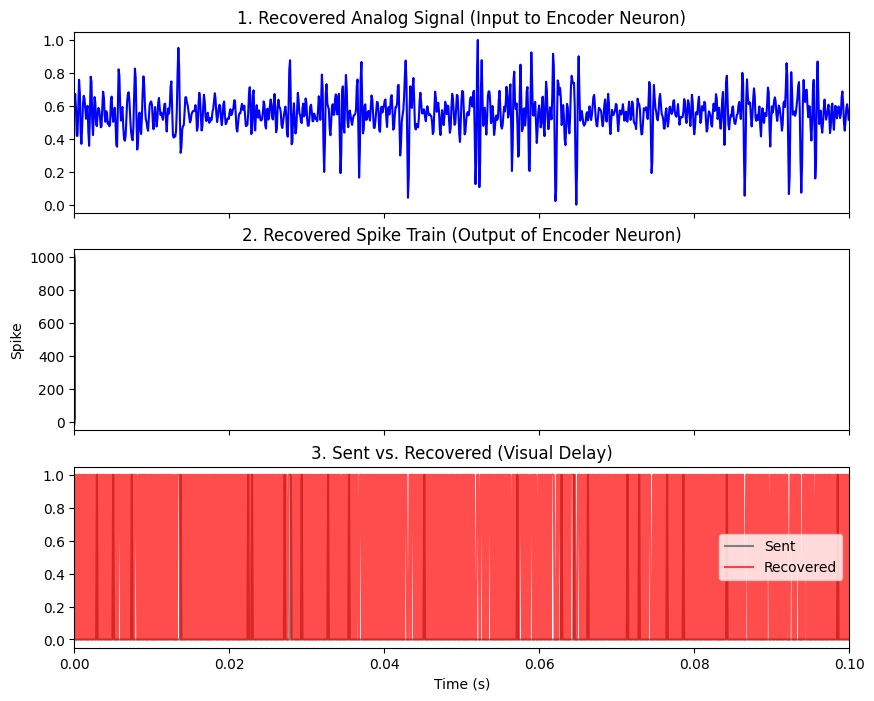

In [2]:
# --- 1. Environment & Physics Setup ---
c = 343  # Speed of sound (m/s)
wall_distance = 5.0 # Meters

# --- 2. The Physics (Transmission Channel) ---
time_of_flight = (2 * wall_distance) / c
delay_samples = int(time_of_flight * fs)
print(f"Target Distance: {wall_distance}m | Time of Flight: {time_of_flight*1000:.2f} ms ({delay_samples} samples)")

rx_signal_np = np.roll(tx_signal_np, delay_samples)
rx_signal_np = rx_signal_np * 0.5 
noise = np.random.normal(0, 0.2, len(rx_signal_np))
rx_signal_np = rx_signal_np + noise

# --- 3. The Receiver (Demodulate & Matched Filter) ---
demod_raw = rx_signal_np * carrier_np
sos = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
rx_baseband = signal.sosfilt(sos, demod_raw)
matched_filter = chirp_template_np[::-1]
recovered_analog_signal = signal.convolve(rx_baseband, matched_filter, mode='same')
# Normalize to act as a current (0-1 range)
recovered_analog_signal = (recovered_analog_signal - recovered_analog_signal.min()) / (recovered_analog_signal.max() - recovered_analog_signal.min())
recovered_analog_current = torch.tensor(recovered_analog_signal).float()

# --- 4. NEW: SNN Spike Encoder ---
# This neuron converts the analog peaks back into digital spikes
lif_encoder = snn.Leaky(beta=0.8, threshold=0.7) # Tune beta/thresh to be sensitive
mem_enc = lif_encoder.init_leaky()
spk_rec = []
for step in range(time_steps):
    spk, mem_enc = lif_encoder(recovered_analog_current[step], mem_enc)
    spk_rec.append(spk)
recovered_spikes = torch.stack(spk_rec).squeeze()

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t_vec, recovered_analog_current, color='blue')
ax[0].set_title("1. Recovered Analog Signal (Input to Encoder Neuron)")

# Use snntorch.spikeplot for the raster
splt.raster(recovered_spikes.unsqueeze(1).T, ax[1], c='black', marker='|')
ax[1].set_title("2. Recovered Spike Train (Output of Encoder Neuron)")
ax[1].set_ylabel("Spike")

ax[2].plot(t_vec, sent_spikes, color='gray', label="Sent")
ax[2].plot(t_vec, recovered_spikes, color='red', alpha=0.7, label="Recovered")
ax[2].set_title("3. Sent vs. Recovered (Visual Delay)")
ax[2].set_xlabel("Time (s)")
ax[2].legend()
plt.xlim(0, T)
plt.show()

### Cell 3: The SNN Cross-Correlator ("Bat Brain")

This cell is the "Bat Brain." It builds a bank of coincidence-detecting neurons. Each neuron i is "tuned" to a specific time delay i. It receives two inputs: the sent_spikes (delayed by i) and the recovered_spikes (no delay). The neuron that fires the most is the one whose internal delay i matches the real-world time-of-flight.

Creating SNN Correlator with 400 neurons (1 per 0.10ms step).
Running SNN Correlator... (This may take a moment)
SNN Run Complete.
--- RESULTS (SNN) ---
Actual Wall Distance:    5.0 m
Calculated Distance:     0.3430 m
Error:                   4.6570 m


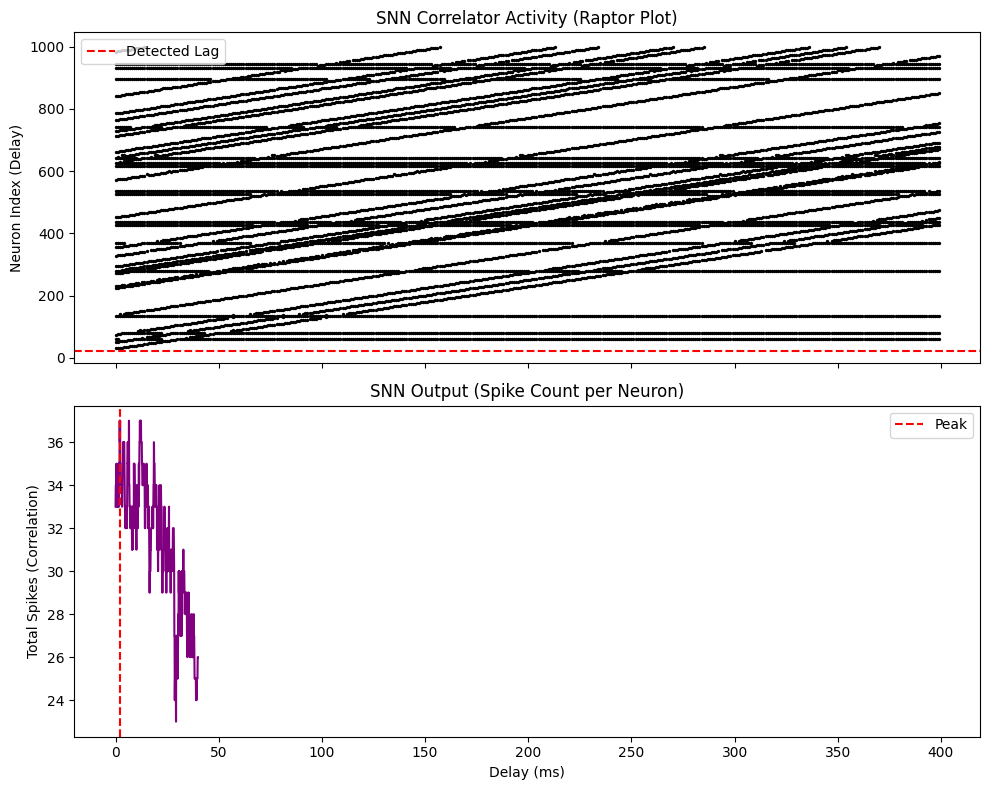

In [3]:
# --- 1. SNN Correlator Parameters ---
# Define the search range for the delay
max_delay_ms = 40.0 # Search from 0 to 40ms
num_neurons = int((max_delay_ms / 1000) * fs) # One neuron for each delay step
print(f"Creating SNN Correlator with {num_neurons} neurons (1 per {1000/fs:.2f}ms step).")

# --- 2. Create the Coincidence Detector Bank (Paper 4) ---
# Low beta (fast leak) & high threshold (needs 2 inputs)
beta_coincidence = 0.5 
thresh_coincidence = 1.8 # Needs two inputs (1.0 + 1.0) to fire
lif_bank = snn.Leaky(beta=beta_coincidence, threshold=thresh_coincidence)

# --- 3. Prepare Input Tensors ---
# We need to create the delayed input for the "Sent" spikes
# in_sent[t, i] will be sent_spikes[t - i]
# in_recv[t, i] will be recovered_spikes[t]
in_sent_delayed = torch.zeros(time_steps, num_neurons)
in_recv_broadcast = torch.zeros(time_steps, num_neurons)

# Create the delayed "Sent" matrix
for i in range(num_neurons):
    in_sent_delayed[:, i] = torch.roll(sent_spikes, shifts=i)
    in_sent_delayed[:i, i] = 0 # Zero out the wrapped-around part
    
# Create the broadcast "Received" matrix
in_recv_broadcast = recovered_spikes.unsqueeze(1).expand(-1, num_neurons)

# Total input: each neuron `i` gets the sum of sent[t-i] and recv[t]
# We scale them so they sum to > threshold (e.g., 1.0 + 1.0)
total_input = (in_sent_delayed * 1.0) + (in_recv_broadcast * 1.0)

# --- 4. Run the SNN Correlator ---
mem = lif_bank.init_leaky()
spk_rec = []
print("Running SNN Correlator... (This may take a moment)")
# Loop through time (snntorch is recurrent)
for step in range(time_steps):
    spk, mem = lif_bank(total_input[step], mem) # total_input[step] is [num_neurons]
    spk_rec.append(spk)
print("SNN Run Complete.")
spk_out = torch.stack(spk_rec) # Shape: [time_steps, num_neurons]

# --- 5. Analyze the Results ---
# Sum the spikes for each neuron. The winning neuron is our delay.
spike_counts = torch.sum(spk_out, dim=0) # Sum over time
detected_lag_steps = torch.argmax(spike_counts) # Find the neuron that fired most
detected_delay_time = detected_lag_steps / fs
calculated_distance = (c * detected_delay_time) / 2

print(f"--- RESULTS (SNN) ---")
print(f"Actual Wall Distance:    {wall_distance} m")
print(f"Calculated Distance:     {calculated_distance.item():.4f} m")
print(f"Error:                   {abs(wall_distance - calculated_distance.item()):.4f} m")

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: The Raster Plot (The "Raptor Plot")
splt.raster(spk_out.T, ax[0], s=2, c='black') # Transpose for [neurons, time]
ax[0].set_title("SNN Correlator Activity (Raptor Plot)")
ax[0].set_ylabel("Neuron Index (Delay)")
ax[0].axhline(detected_lag_steps.item(), color='red', linestyle='--', label="Detected Lag")
ax[0].legend()

# Plot 2: The Correlation Function (Spike Counts)
neuron_lags_ms = torch.arange(num_neurons) * (1000/fs)
ax[1].plot(neuron_lags_ms, spike_counts, color='purple')
ax[1].axvline(detected_delay_time.item() * 1000, color='red', linestyle='--', label="Peak")
ax[1].set_title("SNN Output (Spike Count per Neuron)")
ax[1].set_xlabel("Delay (ms)")
ax[1].set_ylabel("Total Spikes (Correlation)")
ax[1].legend()

plt.tight_layout()
plt.show()